# Flow Matching: 8 Gaussians → Double Moon — Batch Size Comparison

Trains and visualizes **OT-Harmonic (ω=π/3)** across five batch sizes:

1. **batch_size = 1**
2. **batch_size = 10**
3. **batch_size = 100**
4. **batch_size = 200**
5. **batch_size = 300**

Source: 8 Gaussians · Target: Double Moon · Method: `ExactOptimalTransportHarmonicConditionalFlowMatcher(omega=math.pi / 3)`

In [7]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchdyn
from torchdyn.core import NeuralODE

from torchlfm.conditional_flow_matching import (
    ExactOptimalTransportHarmonicConditionalFlowMatcher,
)
from torchlfm.models.models import MLP
from torchlfm.utils import sample_8gaussians, sample_moons, torch_wrapper

savedir = "models/8gaussian-moons-batchsize"
os.makedirs(savedir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def plot_traj(traj, n=2000):
    plt.figure(figsize=(6, 6))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.2, alpha=0.2, c="olive")
    plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")
    plt.axis("off")
    plt.show()

### OT-Harmonic ω=π/3, OT batch_size=1, train batch=100

5000: loss 10.316 time 107.75
10000: loss 11.092 time 106.06
15000: loss 9.619 time 108.86
20000: loss 10.829 time 106.47


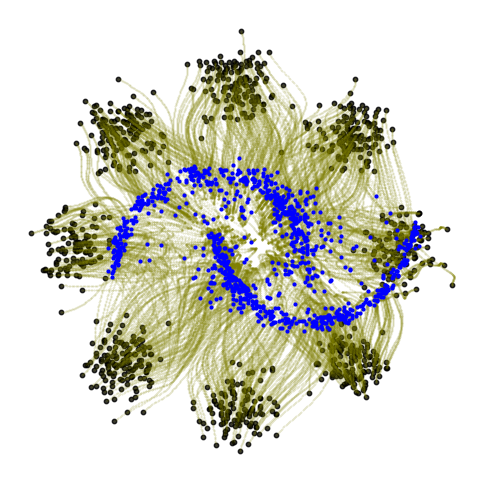

CPU times: user 7min 1s, sys: 7.07 s, total: 7min 8s
Wall time: 7min 11s


In [11]:
%%time
sigma = 0.0
dim = 2
batch_size = 1
TRAIN_BATCH = 100
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=math.pi / 3)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(TRAIN_BATCH).to(device)
    x1 = sample_moons(TRAIN_BATCH).to(device)

    repeats = TRAIN_BATCH // batch_size
    t_list = [None] * repeats
    xt_list = [None] * repeats
    ut_list = [None] * repeats
    for idx, i in enumerate(range(0, TRAIN_BATCH, batch_size)):
        t_list[idx], xt_list[idx], ut_list[idx] = FM.sample_location_and_conditional_flow(
            x0[i:i+batch_size], x1[i:i+batch_size]
        )
    t = torch.cat(t_list)
    xt = torch.cat(xt_list)
    ut = torch.cat(ut_list)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_wpi3_bs1.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

### OT-Harmonic ω=π/3, OT batch_size=10, train batch=100

In [ ]:
%%time
sigma = 0.0
dim = 2
batch_size = 10
TRAIN_BATCH = 100
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=math.pi / 3)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(TRAIN_BATCH).to(device)
    x1 = sample_moons(TRAIN_BATCH).to(device)

    repeats = TRAIN_BATCH // batch_size
    t_list = [None] * repeats
    xt_list = [None] * repeats
    ut_list = [None] * repeats
    for idx, i in enumerate(range(0, TRAIN_BATCH, batch_size)):
        t_list[idx], xt_list[idx], ut_list[idx] = FM.sample_location_and_conditional_flow(
            x0[i:i+batch_size], x1[i:i+batch_size]
        )
    t = torch.cat(t_list)
    xt = torch.cat(xt_list)
    ut = torch.cat(ut_list)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_wpi3_bs10.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

CPU times: user 4.4 ms, sys: 6.25 ms, total: 10.6 ms
Wall time: 10.3 ms


IndexError: list assignment index out of range

### OT-Harmonic ω=π/3, OT batch_size=20, train batch=100

5000: loss 9.763 time 17.86
10000: loss 8.257 time 17.82
15000: loss 5.925 time 17.97
20000: loss 5.654 time 18.06


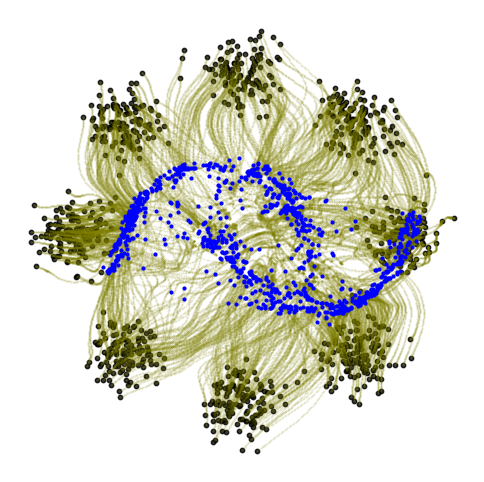

CPU times: user 1min 11s, sys: 4.22 s, total: 1min 15s
Wall time: 1min 13s


In [ ]:
%%time
sigma = 0.0
dim = 2
batch_size = 25
TRAIN_BATCH = 100
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=math.pi / 3)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(TRAIN_BATCH).to(device)
    x1 = sample_moons(TRAIN_BATCH).to(device)

    repeats = TRAIN_BATCH // batch_size
    t_list = [None] * repeats
    xt_list = [None] * repeats
    ut_list = [None] * repeats
    for idx, i in enumerate(range(0, TRAIN_BATCH, batch_size)):
        t_list[idx], xt_list[idx], ut_list[idx] = FM.sample_location_and_conditional_flow(
            x0[i:i+batch_size], x1[i:i+batch_size]
        )
    t = torch.cat(t_list)
    xt = torch.cat(xt_list)
    ut = torch.cat(ut_list)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_wpi3_bs20.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

### OT-Harmonic ω=π/3, OT batch_size=50, train batch=100

In [ ]:
%%time
sigma = 0.0
dim = 2
batch_size = 50
TRAIN_BATCH = 100
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=math.pi / 3)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(TRAIN_BATCH).to(device)
    x1 = sample_moons(TRAIN_BATCH).to(device)

    repeats = TRAIN_BATCH // batch_size
    t_list = [None] * repeats
    xt_list = [None] * repeats
    ut_list = [None] * repeats
    for idx, i in enumerate(range(0, TRAIN_BATCH, batch_size)):
        t_list[idx], xt_list[idx], ut_list[idx] = FM.sample_location_and_conditional_flow(
            x0[i:i+batch_size], x1[i:i+batch_size]
        )
    t = torch.cat(t_list)
    xt = torch.cat(xt_list)
    ut = torch.cat(ut_list)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_wpi3_bs50.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())

CPU times: user 3.89 ms, sys: 1.54 ms, total: 5.43 ms
Wall time: 5.15 ms


IndexError: list assignment index out of range

### OT-Harmonic ω=π/3, OT batch_size=100, train batch=100

5000: loss 0.361 time 17.86
10000: loss 0.262 time 17.66
15000: loss 0.605 time 18.00
20000: loss 0.368 time 17.53


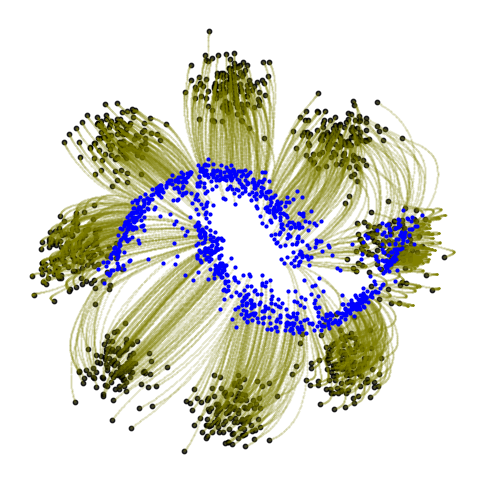

CPU times: user 1min 6s, sys: 6.9 s, total: 1min 13s
Wall time: 1min 13s


In [13]:
%%time
sigma = 0.0
dim = 2
batch_size = 100
TRAIN_BATCH = 100
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters())

FM = ExactOptimalTransportHarmonicConditionalFlowMatcher(sigma=sigma, omega=math.pi / 3)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(TRAIN_BATCH).to(device)
    x1 = sample_moons(TRAIN_BATCH).to(device)

    repeats = TRAIN_BATCH // batch_size
    t_list = [None] * repeats
    xt_list = [None] * repeats
    ut_list = [None] * repeats
    for idx, i in enumerate(range(0, TRAIN_BATCH, batch_size)):
        t_list[idx], xt_list[idx], ut_list[idx] = FM.sample_location_and_conditional_flow(
            x0[i:i+batch_size], x1[i:i+batch_size]
        )
    t = torch.cat(t_list)
    xt = torch.cat(xt_list)
    ut = torch.cat(ut_list)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

torch.save(model, f"{savedir}/ot_harmonic_wpi3_bs100.pt")
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1024).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )
plot_traj(traj.cpu().numpy())